Shape of smoke volume['raw']: (125, 1250, 1250)


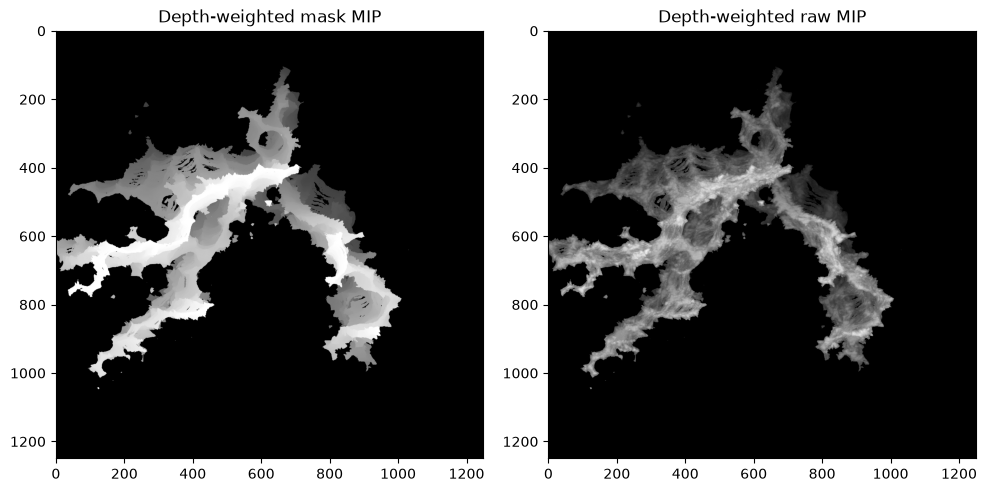

In [12]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import h5py as h5
vol = h5.File('../data/smoke_data/sample_A_20160501.hdf', 'r')
vol.keys()
images = vol['volumes']
segments = vol['annotations']

print('Shape of smoke volume[\'raw\']:', images['raw'].shape)
neuron_ids = np.array(images['labels']['neuron_ids'])  # copy, so this doesn't mutate images[...] in place
mask = neuron_ids == 20474        # compute the boolean mask once, before any mutation

ids, counts = np.unique(neuron_ids, return_counts=True)
most_frequent_label = ids[np.argmax(counts)]   # need the ids[...] lookup!
# list of all neuron_ids that are present in the volume, sorted by frequency
sorted_neuron_ids = ids[np.argsort(counts)[::-1]]
sorted_counts = counts[np.argsort(counts)[::-1]]
sorted_neuron_ids, sorted_counts  # top 10 neuron_ids and their counts

# Depth weights make near voxels brighter and far voxels darker along the camera sight.
# This is a simple depth cue on top of the MIP rather than a plain max projection.
depth_weights = np.linspace(1.0, 0.25, images['raw'].shape[0], dtype=np.float32)[:, None, None]
weighted_mask = mask.astype(np.float32) * depth_weights
weighted_raw = images['raw'].astype(np.float32) * weighted_mask

plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(np.max(weighted_mask, axis=0), cmap='gray', vmin=0, vmax=1)
plt.title('Depth-weighted mask MIP')
plt.subplot(1, 2, 2)
plt.imshow(np.max(weighted_raw, axis=0), cmap='gray')
plt.title('Depth-weighted raw MIP')
plt.tight_layout()

## 3D Gaussian Rasterization: Formula Notes

This cell records the rasterization math in LaTeX-rendered form.

### 1. Gaussian field

For Gaussian $i$, the contribution at a 3D point $\mathbf{x} \in \mathbb{R}^3$ is

$$
f_i(\mathbf{x})
= I_i \, \exp\!\left(-\tfrac{1}{2}(\mathbf{x}-\boldsymbol\mu_i)^\top \mathbf{\Sigma}_i^{-1}(\mathbf{x}-\boldsymbol\mu_i)\right),
$$

where

$$
F(\mathbf{x}) = \sum_{i=1}^{N} f_i(\mathbf{x}).
$$

Here $\boldsymbol\mu_i \in \mathbb{R}^3$ is the Gaussian mean, $\mathbf{\Sigma}_i \in \mathbb{R}^{3\times 3}$ is the covariance, and $I_i$ is the intensity / opacity weight.

### 2. Quaternion parameterization

The quaternion convention is

$$
\mathbf{q}_i = [w_i, x_i, y_i, z_i].
$$

After normalization,

$$
\mathbf{q}_i \leftarrow \frac{\mathbf{q}_i}{\|\mathbf{q}_i\|}.
$$

The corresponding rotation matrix $\mathbf{R}_i$ is built from that ordering.

### 3. Covariance from scales and rotation

Per-axis scales are recovered from log-scales by

$$
\mathbf{s}_i = \exp(\log \mathbf{s}_i).
$$

The covariance is then

$$
\mathbf{\Sigma}_i = \mathbf{R}_i\,\operatorname{diag}(\mathbf{s}_i^2)\,\mathbf{R}_i^\top.
$$

### 4. Camera transform

Let the view matrix be

$$
\mathbf{V} =
\begin{bmatrix}
\mathbf{R}_V & \mathbf{t}_V \\
\mathbf{0}^\top & 1
\end{bmatrix}.
$$

Using homogeneous coordinates,

$$
\mathbf{x}_i^{\mathrm{cam}} = \mathbf{V}\begin{bmatrix} \boldsymbol\mu_i \\ 1 \end{bmatrix}.
$$

The camera-space covariance is

$$
\mathbf{\Sigma}_i^{\mathrm{cam}} = \mathbf{R}_V\,\mathbf{\Sigma}_i\,\mathbf{R}_V^\top,
$$

and the depth is

$$
 d_i = \mathbf{x}_{i,z}^{\mathrm{cam}}.
$$

### 5. Projection to screen space

Let $\mathbf{P}$ be the projection matrix. Then

$$
\mathbf{x}_i^{\mathrm{clip}} = \mathbf{P}\,\mathbf{x}_i^{\mathrm{cam}}.
$$

The screen-space center is

$$
 u_i = \frac{x_{i,x}^{\mathrm{clip}}}{x_{i,w}^{\mathrm{clip}}},
 \qquad
 v_i = \frac{x_{i,y}^{\mathrm{clip}}}{x_{i,w}^{\mathrm{clip}}}.
$$

If $\mathbf{J}_i$ is the Jacobian of the projection evaluated at $\boldsymbol\mu_i^{\mathrm{cam}}$, then

$$
\mathbf{\Sigma}_i^{\mathrm{screen}} = \mathbf{J}_i\,\mathbf{\Sigma}_i^{\mathrm{cam}}\,\mathbf{J}_i^\top,
\qquad
\mathbf{Q}_i = \left(\mathbf{\Sigma}_i^{\mathrm{screen}}\right)^{-1}.
$$

### 6. Elliptical footprint

For a pixel $\mathbf{p} = (u, v)$, the Gaussian footprint is

$$
g_i(\mathbf{p})
= \exp\!\left(-\tfrac{1}{2}(\mathbf{p} - \boldsymbol\mu_i^{\mathrm{screen}})^\top
\mathbf{Q}_i
(\mathbf{p} - \boldsymbol\mu_i^{\mathrm{screen}})\right).
$$

The per-pixel weight is

$$
w_i(\mathbf{p}) = I_i\,g_i(\mathbf{p}).
$$

### 7. Depth-aware compositing

Sort Gaussians by depth so nearer splats are processed first. A standard alpha accumulation is

$$
\mathbf{C}(\mathbf{p}) = \sum_{i=1}^{N} T_i(\mathbf{p})\,\alpha_i(\mathbf{p})\,\mathbf{c}_i,
$$

with transmittance

$$
T_i(\mathbf{p}) = \prod_{j<i} \left(1 - \alpha_j(\mathbf{p})\right).
$$

If a depth cue is desired, define

$$
\beta_i = \exp\!\left(-\lambda\,\max(d_i - d_{\mathrm{ref}}, 0)\right),
$$

and use

$$
\alpha_i'(\mathbf{p}) = \alpha_i(\mathbf{p})\,\beta_i.
$$

### 8. Final output

The final image is

$$
I_{\mathrm{out}}(\mathbf{p}) = \operatorname{clamp}\left(\mathbf{C}(\mathbf{p}), 0, 1\right).
$$

For grayscale rendering, the accumulated intensity can be used directly after clamping.


In [6]:
# render_sliding_block: puts the camera at the sliding window's centre and
# rotates 360 degrees looking outward, using only the Gaussians whose mean
# falls inside the window (pulled from block_cache). Logic lives in
# scripts/render_scripts/sliding_window_camera.py — this cell just imports it.
from scripts.render_scripts.sliding_window_camera import render_sliding_block

In [7]:
# Quick sanity check on one block directly (no stitching) — just to confirm
# the raw block data itself looks right before navigating with the Gaussians.
import h5py as h5_check
with h5_check.File('../data/smoke_data/blocks/block_z0_y1_x6.h5', 'r') as f:
    block_raw = f['raw'][:]
print('block_z0_y1_x6 raw shape:', block_raw.shape)
# plt.imshow(block_raw[0], cmap='gray')

block_z0_y1_x6 raw shape: (50, 50, 50)


In [8]:
%matplotlib inline
# Directly run the CUDA eval kernel inside the sliding cube, then compare it
# against the GT DVR/MIP render from the same cube. The splat result is a
# blob-like Gaussian projection; the GT view is what carries the volume detail.
import time
import importlib
import numpy as np
import torch
import matplotlib.pyplot as plt

import scripts.render_scripts.sliding_window_camera as swc
swc = importlib.reload(swc)
from scripts.render_scripts.render_camera import render_frame
from scripts._3dgs._3dgs import _load_eval_kernel

center_zyx = (62, 75, 75)
block_size = 32
img_size = 256
azimuth_deg = 0.0

# Reuse the existing block_cache (no separate cache, no stitched_volume needed).
windowed_gc = block_cache.get_gaussians_for_window(center_zyx, block_size)
local_gc, bounds = swc.filter_gaussians_in_block(windowed_gc, center_zyx, block_size, block_cache.global_shape)
means, log_s = swc.recenter_and_rescale(local_gc, bounds)

# Rotate the world by -azimuth so the fixed Z-projection matches the camera yaw.
theta = torch.tensor(-np.radians(azimuth_deg), device=means.device, dtype=means.dtype)
c, s = torch.cos(theta), torch.sin(theta)
R_y = torch.tensor([[c, 0.0, s], [0.0, 1.0, 0.0], [-s, 0.0, c]], device=means.device, dtype=means.dtype)
means_rot = means @ R_y.T
q_delta = torch.stack([
    torch.cos(theta / 2),
    torch.zeros((), device=means.device, dtype=means.dtype),
    torch.sin(theta / 2),
    torch.zeros((), device=means.device, dtype=means.dtype),
]).unsqueeze(0).expand(means.shape[0], 4)
quats_rot = swc.quat_multiply(q_delta, local_gc.quats)

kernel = _load_eval_kernel()
if torch.cuda.is_available():
    torch.cuda.synchronize()
t0 = time.perf_counter()
flat = kernel.splat_mip(
    means_rot.contiguous(),
    log_s.contiguous(),
    quats_rot.contiguous(),
    local_gc.inten.contiguous(),
    -1.0, 1.0, -1.0, 1.0, -1.0, 1.0,
    img_size, img_size, 32, 0,
    float(local_gc.scale_min), float(local_gc.mahal_clamp),
)
if torch.cuda.is_available():
    torch.cuda.synchronize()
splat_ms = (time.perf_counter() - t0) * 1000
splat_frame = flat.reshape(img_size, img_size).clamp(0, 1).cpu().numpy().astype(np.float32)

# Build the GT cube from the same sliding window, then render it with DVR/MIP.
gt_vol = swc.reconstruct_local_cube(local_gc, bounds, block_size, block_cache.device)
if torch.cuda.is_available():
    torch.cuda.synchronize()
t0 = time.perf_counter()
gt_frame = render_frame(gt_vol, azimuth_deg=0.0, elev_deg=0.0, fov_deg=90.0, img_h=img_size, img_w=img_size, n_steps=128)
if torch.cuda.is_available():
    torch.cuda.synchronize()
gt_ms = (time.perf_counter() - t0) * 1000

print(f'Direct CUDA eval kernel inside sliding cube: {splat_ms:.1f} ms for {img_size}x{img_size}')
print(f'GT DVR/MIP inside same cube: {gt_ms:.1f} ms for {img_size}x{img_size}')
print(f'Gaussians inside cube: {local_gc.means.shape[0]:,}')

fig, axs = plt.subplots(1, 3, figsize=(14, 4))
axs[0].imshow(gt_frame, cmap='gray', vmin=0, vmax=1)
axs[0].set_title('GT DVR/MIP')
axs[1].imshow(splat_frame, cmap='gray', vmin=0, vmax=1)
axs[1].set_title('direct splat_mip')
axs[2].imshow(np.abs(gt_frame - splat_frame), cmap='magma')
axs[2].set_title('abs diff')
plt.tight_layout()
plt.show()


/root/project/scripts/_3dgs/_3dgs.py:1008: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(str(path), map_location="cpu")


  window overlaps blocks [(0, 1, 1), (1, 1, 1)] (2 resident in cache)


/venv/r3-ml/lib/python3.11/site-packages/torch/utils/cpp_extension.py:1964: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


Direct CUDA eval kernel inside sliding cube: 8.8 ms for 256x256
GT DVR/MIP inside same cube: 896.4 ms for 256x256
Gaussians inside cube: 13,876


/tmp/ipykernel_816954/4145367966.py:79: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [6]:
h5py_file_path = '../data/smoke_data/blocks/block_z0_y1_x6.h5'
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import h5py as h5
vol = h5.File(h5py_file_path, 'r')
# vol.keys()
images = vol
# segments = vol['annotations']

print('Shape of smoke volume[\'raw\']:', images['raw'].shape)
# neuron_ids = np.array(images)  # copy, so this doesn't mutate images[...] in place
# mask = neuron_ids == 20474        # compute the boolean mask once, before any mutation

# ids, counts = np.unique(neuron_ids, return_counts=True)
# most_frequent_label = ids[np.argmax(counts)]   # need the ids[...] lookup!
# list of all neuron_ids that are present in the volume, sorted by frequency
# sorted_neuron_ids = ids[np.argsort(counts)[::-1]]
# sorted_counts = counts[np.argsort(counts)[::-1]]
# sorted_neuron_ids, sorted_counts  # top 10 neuron_ids and their counts

# Depth weights make near voxels brighter and far voxels darker along the camera sight.
# This is a simple depth cue on top of the MIP rather than a plain max projection.
depth_weights = np.linspace(1.0, 0.25, images['raw'].shape[0], dtype=np.float32)[:, None, None]
# weighted_mask = mask.astype(np.float32) * depth_weights
weighted_raw = images['raw'].astype(np.float32) * depth_weights



Shape of smoke volume['raw']: (50, 50, 50)


[coords] means range: x [-1.0000, 1.0000] y [-1.0000, 1.0000] z [-1.0000, 1.0000]
[render] 50000 gaussians (50000 kept) in 0.009s at 50x50
[slabs]  n=54, width=0.0370, median axial sigma=0.0245 (ratio 1.51; aim ~1-2)
[debug] GT weighted MIP:  min=94.8571 max=169.3674 mean=146.6986 std=14.0931
[debug] pred (rendered):  min=0.3241 max=0.9766 mean=0.6880 std=0.0920
[debug] GT peak at (y,x)=(np.int64(8), np.int64(19)) (shape (50, 50)); pred peak at (y,x)=(np.int64(45), np.int64(6)) (shape (50, 50))


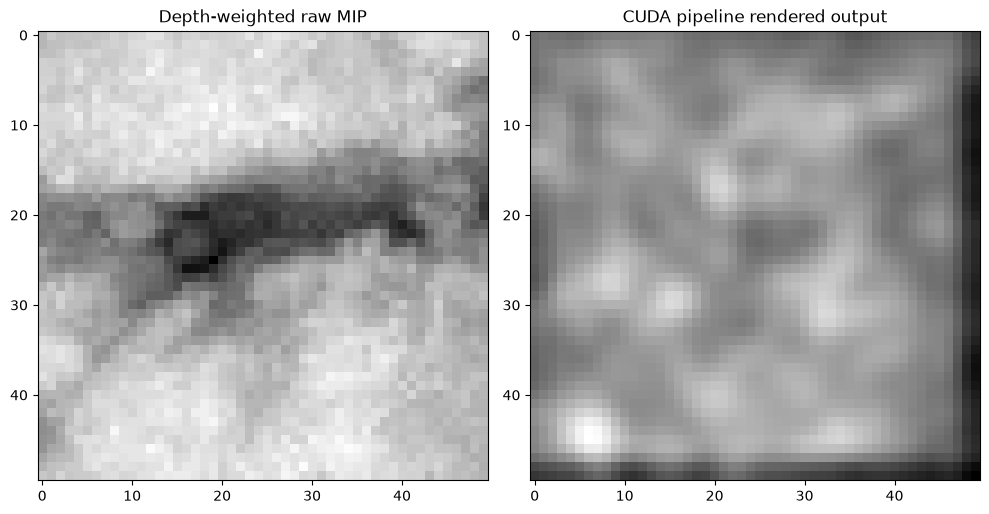

In [17]:
from pathlib import Path
from time import time
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.cpp_extension import load
from scripts._3dgs._3dgs import _find_cuda_include

PROJECT_ROOT = Path('/root/project')
CKPT_DIR = PROJECT_ROOT / 'models_smoke' / 'block_z000_y001_x006' / 'best.pth'
CUDA_SRC = PROJECT_ROOT / 'scripts' / 'render_scripts' / 'smoke_raster_cuda.cu'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type != 'cuda':
    raise RuntimeError('This cell requires CUDA to run the raster pipeline')


def gather_inputs(ckpt_dir, device):
    loaded_ckpt = torch.load(str(ckpt_dir), map_location='cpu', weights_only=True)
    means = loaded_ckpt['means'].to(device, dtype=torch.float32).contiguous()
    log_scales = loaded_ckpt['log_scales'].to(device, dtype=torch.float32).contiguous()
    # NOTE: transform_kernel assumes (w, x, y, z) quaternions. If the training
    # code parameterized (x, y, z, w), reorder here:
    #   quats = loaded_ckpt['quats'][:, [3, 0, 1, 2]]
    quats = loaded_ckpt['quats'].to(device, dtype=torch.float32).contiguous()
    inten = F.softplus(loaded_ckpt['intensities'].to(device, dtype=torch.float32)).contiguous()
    return means, log_scales, quats, inten


_smoke_cuda = None


def _load_smoke_cuda_pipeline():
    global _smoke_cuda
    if _smoke_cuda is None:
        extra_inc = _find_cuda_include()
        extra_flags = ['-O3', '--use_fast_math'] + [f'-I{p}' for p in extra_inc]
        _smoke_cuda = load(
            name='smoke_raster_cuda',
            sources=[str(CUDA_SRC)],
            extra_cuda_cflags=extra_flags,
            extra_include_paths=extra_inc,
            verbose=False,
        )
    return _smoke_cuda


def fit_orthographic_projection(means, margin=0.05):
    """Orthographic projection mapping the checkpoint's actual xy extent to
    NDC [-1, 1]. With identity view/projection the previous version implicitly
    assumed means already lived in [-1, 1]; if they live in e.g. [0, 1] (or
    voxel coordinates), everything renders into one corner of the screen --
    which is exactly what a border-adjacent predicted peak looks like."""
    mn = means.min(0).values
    mx = means.max(0).values
    center = (mn + mx) / 2
    extent = (mx - mn) / 2 * (1.0 + margin)
    extent = torch.clamp(extent, min=1e-6)
    P = torch.eye(4, device=means.device, dtype=torch.float32)
    P[0, 0] = 1.0 / extent[0]
    P[0, 3] = -center[0] / extent[0]
    P[1, 1] = 1.0 / extent[1]
    P[1, 3] = -center[1] / extent[1]
    # z passes through untouched (w == 1 everywhere: no perspective divide);
    # depth slabs use camera-space z directly, so no z remap is needed here.
    return P, mn, mx


def choose_num_slabs(kept_depths, log_scales, keep_mask, max_slabs=64, target_ratio=1.5):
    """Pick the slab count so slab width lands near target_ratio x the median
    axial sigma (the regime where mean-depth binning neither pops between
    slabs nor degenerates toward a plain sum)."""
    span = (kept_depths.max() - kept_depths.min()).item()
    median_sigma_z = torch.exp(log_scales[keep_mask.bool(), 2]).median().item()
    if median_sigma_z <= 0 or span <= 0:
        return 16, float('nan'), median_sigma_z
    n = int(round(span / (target_ratio * median_sigma_z)))
    n = max(1, min(n, max_slabs))
    return n, span / n, median_sigma_z


def compare_to_gt(pred, gt):
    """Compare RAW rendered intensity to GT on the same grid.

    Raw values are not expected to match (arbitrary global scale between the
    model's intensity units and the GT's), so the meaningful metrics are
    Pearson correlation and z-scored L2. Also searches the 8 flip/transpose
    orientations, since an axis-convention mismatch between the GT MIP and
    (u_px, v_px) is the classic residual after the projection is fixed."""
    assert pred.shape == gt.shape, f'shape mismatch: pred {pred.shape} vs gt {gt.shape}'
    gt_z = (gt - gt.mean()) / (gt.std() + 1e-12)

    def stats(p):
        p_z = (p - p.mean()) / (p.std() + 1e-12)
        corr = float((p_z * gt_z).mean())
        zl2 = float(np.sqrt(((p_z - gt_z) ** 2).mean()))
        return corr, zl2

    orientations = {
        'identity': pred,
        'flipud': np.flipud(pred),
        'fliplr': np.fliplr(pred),
        'flipud+fliplr': np.flipud(np.fliplr(pred)),
        'transpose': pred.T,
        'transpose+flipud': np.flipud(pred.T),
        'transpose+fliplr': np.fliplr(pred.T),
        'transpose+both': np.flipud(np.fliplr(pred.T)),
    }
    results = {name: stats(np.ascontiguousarray(p)) for name, p in orientations.items()}
    best_name = max(results, key=lambda k: results[k][0])
    return results, best_name


def write_final_image(final_image, output_path):
    """Tonemapped preview for viewing ONLY -- never feed this into metrics."""
    rendered = torch.log1p(final_image.clamp_min(0))
    flat = rendered.flatten()
    scale = torch.quantile(flat, 0.995)
    if not torch.isfinite(scale) or scale <= 0:
        scale = rendered.max()
    rendered = torch.clamp(rendered / (scale + 1e-8), 0, 1).pow(0.95)
    rendered = F.pad(rendered.unsqueeze(0).unsqueeze(0), (2, 2, 2, 2), mode='reflect')
    rendered = F.conv2d(
        rendered,
        weight=torch.tensor([[[[1.0, 2.0, 3.0, 2.0, 1.0],
                               [2.0, 4.0, 6.0, 4.0, 2.0],
                               [3.0, 6.0, 9.0, 6.0, 3.0],
                               [2.0, 4.0, 6.0, 4.0, 2.0],
                               [1.0, 2.0, 3.0, 2.0, 1.0]]]], device=rendered.device, dtype=rendered.dtype) / 81.0,
    ).squeeze(0).squeeze(0)
    plt.imsave(output_path, rendered.detach().cpu().numpy(), cmap='gray')


# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
# Set to the GT weighted-MIP array (H, W) as a numpy array or torch tensor to
# enable the comparison block; leave as None to just render.
GT_MIP = None  # e.g.: np.load('gt_weighted_mip.npy')

tile_size = 16
eps = 1e-6
opacity_threshold = 1e-4
# Cue OFF for GT comparison: unless the GT "weighted MIP" uses the identical
# exp(-lambda*(z - d_ref)) weighting, a nonzero lambda compares two
# differently-weighted MIPs and even a perfect render won't match. Re-enable
# (e.g. 0.12) for standalone previews once the geometry is validated.
depth_cue_lambda = 0.0

mod = _load_smoke_cuda_pipeline()
means, log_scales, quats, inten = gather_inputs(CKPT_DIR, device)

# Render at the GT grid so pixel (i, j) corresponds to GT texel (i, j);
# fall back to 128x128 for standalone previews.
if GT_MIP is not None:
    gt = GT_MIP.detach().cpu().numpy() if torch.is_tensor(GT_MIP) else np.asarray(GT_MIP)
    gt = gt.astype(np.float64)
    image_h, image_w = gt.shape
else:
    gt = None
    image_h, image_w = 50, 50

print(f'[coords] means range: x [{means[:, 0].min():.4f}, {means[:, 0].max():.4f}] '
      f'y [{means[:, 1].min():.4f}, {means[:, 1].max():.4f}] '
      f'z [{means[:, 2].min():.4f}, {means[:, 2].max():.4f}]')

camera_view_matrix = torch.eye(4, device=device, dtype=torch.float32)
projection_matrix, mn, mx = fit_orthographic_projection(means)

# Frustum in camera space (= checkpoint coordinates under identity view),
# derived from the actual data extent instead of hard-coded +/-1.25 bounds
# that silently assumed normalized coordinates.
pad = 0.10 * (mx - mn).clamp(min=1e-6)
frustum_bounds = (
    float(mn[0] - pad[0]), float(mx[0] + pad[0]),
    float(mn[1] - pad[1]), float(mx[1] + pad[1]),
    float(mn[2] - pad[2]), float(mx[2] + pad[2]),
)

torch.cuda.synchronize()
start = time()

means_cam, cov_cam, cam_depths = mod.transform_to_camera_space(
    means, log_scales, quats, camera_view_matrix)

u_norm, v_norm, u_px, v_px, ndc_depths, inv_screen_cov, valid_mask = mod.project_to_image_plane(
    means_cam, cov_cam, projection_matrix, image_h, image_w, eps)

# z_forward_sign=0.0: identity view + orthographic projection has no
# behind-camera hemisphere; re-enable (-1.0 for OpenGL-style cameras) once a
# real view matrix goes in.
keep_mask = mod.cull_gaussians(
    means_cam, cam_depths, inten, valid_mask,
    *frustum_bounds, opacity_threshold, z_forward_sign=0.0)

n_kept = int(keep_mask.sum().item())
if n_kept == 0:
    raise RuntimeError(
        f'0 of {means.shape[0]} gaussians survived culling -- '
        f'frustum_bounds {frustum_bounds} vs means range printed above')

# Slab count chosen from the data: previous fixed 16 slabs gave a width/sigma
# ratio of ~5 (sum-ish regime, flat output); target ~1.5 keeps mean-depth
# binning in its valid regime.
kept_depths = cam_depths[keep_mask.bool()]
num_depth_slabs, slab_width, median_sigma_z = choose_num_slabs(
    kept_depths, log_scales, keep_mask)

tile_mask = mod.bin_gaussians_into_tiles(
    u_px, v_px, inv_screen_cov, keep_mask, image_h, image_w, tile_size)

final_image, depth_map = mod.rasterize_scene(
    u_px, v_px, cam_depths, inten, inv_screen_cov, keep_mask, tile_mask,
    image_h, image_w, tile_size,
    num_depth_slabs=num_depth_slabs,
    depth_cue_lambda=depth_cue_lambda)

torch.cuda.synchronize()
elapsed = time() - start

print(f'[render] {means.shape[0]} gaussians ({n_kept} kept) in {elapsed:.3f}s '
      f'at {image_h}x{image_w}')
print(f'[slabs]  n={num_depth_slabs}, width={slab_width:.4f}, '
      f'median axial sigma={median_sigma_z:.4f} '
      f'(ratio {slab_width / max(median_sigma_z, 1e-12):.2f}; aim ~1-2)')

# ---------------------------------------------------------------------------
# GT comparison on RAW intensity (pre-tonemap), same grid, cue off
# ---------------------------------------------------------------------------
if gt is not None:
    pred = final_image.detach().cpu().numpy().astype(np.float64)
    print(f'[raw] pred: min={pred.min():.4f} max={pred.max():.4f} '
          f'mean={pred.mean():.4f} std={pred.std():.4f}')
    print(f'[raw] gt:   min={gt.min():.4f} max={gt.max():.4f} '
          f'mean={gt.mean():.4f} std={gt.std():.4f}')

    gy, gx = np.unravel_index(np.argmax(gt), gt.shape)
    py, px_ = np.unravel_index(np.argmax(pred), pred.shape)
    print(f'[peak] gt at (y,x)=({gy},{gx}), pred at (y,x)=({py},{px_}) '
          f'(same {image_h}x{image_w} grid)')

    results, best = compare_to_gt(pred, gt)
    print('[orient] pearson r / z-scored L2 per orientation:')
    for name, (corr, zl2) in sorted(results.items(), key=lambda kv: -kv[1][0]):
        marker = ' <-- best' if name == best else ''
        print(f'         {name:20s} r={corr:+.4f}  zL2={zl2:.4f}{marker}')
    # If 'identity' isn't best, the winning transform tells you exactly which
    # axis flip/swap separates the GT MIP convention from (u_px, v_px) --
    # bake that into the projection or the GT loader, then re-run and expect
    # 'identity' to win.

write_final_image(final_image, 'rendered_output.png')
%matplotlib inline
rendered = torch.log1p(final_image.clamp_min(0))
flat = rendered.flatten()
scale = torch.quantile(flat, 0.995)
if not torch.isfinite(scale) or scale <= 0:
    scale = rendered.max()
rendered = torch.clamp(rendered / (scale + 1e-8), 0, 1).pow(0.95)
rendered = torch.nn.functional.pad(rendered.unsqueeze(0).unsqueeze(0), (2, 2, 2, 2), mode='reflect')
rendered = torch.nn.functional.conv2d(
    rendered,
    weight=torch.tensor([[[[1.0, 2.0, 3.0, 2.0, 1.0],
                            [2.0, 4.0, 6.0, 4.0, 2.0],
                            [3.0, 6.0, 9.0, 6.0, 3.0],
                            [2.0, 4.0, 6.0, 4.0, 2.0],
                            [1.0, 2.0, 3.0, 2.0, 1.0]]]], device=rendered.device, dtype=rendered.dtype) / 81.0,
).squeeze(0).squeeze(0)

gt_mip = np.max(weighted_raw, axis=0)
pred_np = rendered.detach().cpu().numpy()
if DEBUG:
    print(f'[debug] GT weighted MIP:  min={gt_mip.min():.4f} max={gt_mip.max():.4f} mean={gt_mip.mean():.4f} std={gt_mip.std():.4f}')
    print(f'[debug] pred (rendered):  min={pred_np.min():.4f} max={pred_np.max():.4f} mean={pred_np.mean():.4f} std={pred_np.std():.4f}')
    gt_peak_yx = np.unravel_index(np.argmax(gt_mip), gt_mip.shape)
    pred_peak_yx = np.unravel_index(np.argmax(pred_np), pred_np.shape)
    print(f'[debug] GT peak at (y,x)={gt_peak_yx} (shape {gt_mip.shape}); pred peak at (y,x)={pred_peak_yx} (shape {pred_np.shape})')

plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(gt_mip, cmap='gray')
plt.title('Depth-weighted raw MIP')
plt.subplot(1, 2, 2)
plt.imshow(pred_np, cmap='gray')
plt.title('CUDA pipeline rendered output')
plt.tight_layout()
plt.show()


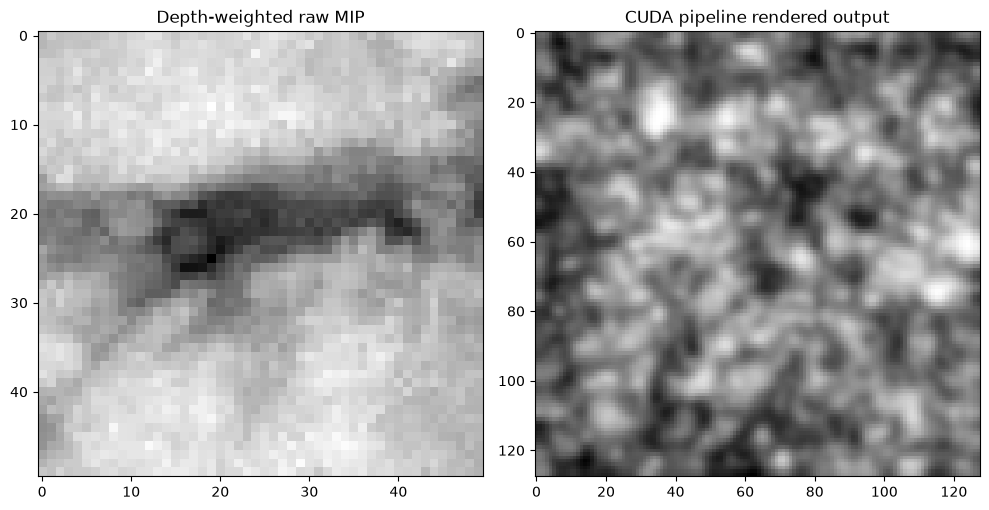